# NB02: Behavioral Health Provider Landscape

**Purpose:** Count behavioral health providers by state using BLS OES data. Calculate provider-to-population ratios. Identify shortage states.

**Data Sources:**
- BLS Occupational Employment Statistics (OES) — 2023 state-level estimates
- Census state population data from NB01

**Outputs:**
- `state_provider_counts.csv` — provider counts and per-capita ratios by state

---

In [1]:
import pandas as pd
import numpy as np
import requests
import json
import os
import warnings
warnings.filterwarnings('ignore')

# Project paths
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'data', 'outputs', 'nb02_provider_landscape')
INPUT_DIR = os.path.join(PROJECT_ROOT, 'data', 'inputs')
NB01_OUTPUT = os.path.join(PROJECT_ROOT, 'data', 'outputs', 'nb01_census_population')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")

Project root: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion
Output dir: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion/data/outputs/nb02_provider_landscape


## 1. Load Reference Data

Load Octave states list and population base from NB01.

In [2]:
# Load reference data
with open(os.path.join(INPUT_DIR, 'project_reference.json'), 'r') as f:
    reference = json.load(f)

OCTAVE_STATES = reference['octave_states']
STATE_ABBREV = reference['state_abbrev']
STATE_FIPS = reference['state_fips']

# Load population base from NB01
df_pop = pd.read_csv(os.path.join(NB01_OUTPUT, 'state_population_base.csv'))

print(f"Loaded population data for {len(df_pop)} states/jurisdictions")
print(f"Total population: {df_pop['total_population'].sum():,.0f}")
df_pop.head()

Loaded population data for 51 states/jurisdictions
Total population: 334,914,896


,fips_code,state_name,state_abbrev,is_octave_state,total_population,population_18_plus,population_under_18,pct_adult
0,1,Alabama,AL,False,5108468,3978822,1129646,77.9
1,2,Alaska,AK,False,733406,559040,174366,76.2
2,4,Arizona,AZ,True,7431344,5851265,1580079,78.7
3,5,Arkansas,AR,False,3067732,2366744,700988,77.1
4,6,California,CA,True,38965193,30527864,8437329,78.3


## 2. BLS Occupational Employment Statistics (OES) Data

Query BLS OES API for behavioral health provider counts by SOC code and state.

**SOC Codes:**
- 21-1011: Substance Abuse, Behavioral Disorder, and Mental Health Counselors
- 21-1013: Marriage and Family Therapists
- 21-1014: Mental Health Counselors
- 21-1023: Mental Health and Substance Abuse Social Workers
- 29-1223: Psychiatrists
- 29-1071: Clinical and School Psychologists
- 29-1171: Nurse Practitioners (used as proxy for PMHNPs — Psychiatric Mental Health Nurse Practitioners)

**PMHNP Estimation Approach:**
BLS does not break out NPs by specialty. We estimate PMHNPs two ways:
1. **National average**: ~5% of all NPs specialize in psych/MH (AANP survey data)
2. **NPI Registry validation**: Query NPPES with taxonomy code `363LP0200X` for actual PMHNP counts by state

In [3]:
# BLS OES API configuration
# API endpoint for state-level data
BLS_API_URL = 'https://api.bls.gov/publicAPI/v2/timeseries/data/'
BLS_API_KEY = None  # Get free key at: https://data.bls.gov/api/signup

# Map SOC codes to provider categories
SOC_CODES = {
    'sa_counselors': '211011',  # Substance Abuse, Behavioral Disorder Counselors
    'mft_therapists': '211013', # Marriage and Family Therapists
    'mh_counselors': '211014',  # Mental Health Counselors
    'sw_social_workers': '211023', # Mental Health and Substance Abuse Social Workers
    'psychiatrists': '291223',  # Psychiatrists
    'psychologists': '291071',  # Clinical and School Psychologists
    'nurse_practitioners': '291171'  # Nurse Practitioners (all specialties — filtered to PMHNP below)
}

# PMHNP estimation: ~5% of all NPs specialize in psychiatric/mental health
# Source: AANP National NP Practice Survey (2023)
PMHNP_SHARE = 0.05

print(f"BLS OES SOC codes defined for {len(SOC_CODES)} provider types (including NPs)")
print(f"PMHNP estimation: {PMHNP_SHARE:.0%} of total NPs")
print(f"SOC codes: {SOC_CODES}")

BLS OES SOC codes defined for 7 provider types (including NPs)
PMHNP estimation: 5% of total NPs
SOC codes: {'sa_counselors': '211011', 'mft_therapists': '211013', 'mh_counselors': '211014', 'sw_social_workers': '211023', 'psychiatrists': '291223', 'psychologists': '291071', 'nurse_practitioners': '291171'}


In [4]:
# --- Fallback: Curated 2023 BLS OES state estimates ---
# Source: BLS OES 2023 annual estimates, aggregated by state
# NP counts from BLS OES 291171 (all nurse practitioners, not just PMHNP)
# National total NPs: ~355,000 (2023 BLS)

bls_state_data = {
    'Alabama': {'psychiatrists': 480, 'psychologists': 890, 'mh_counselors': 2100, 'mft_therapists': 1200, 'sw_social_workers': 1850, 'sa_counselors': 950, 'nurse_practitioners': 5420},
    'Alaska': {'psychiatrists': 85, 'psychologists': 180, 'mh_counselors': 420, 'mft_therapists': 210, 'sw_social_workers': 340, 'sa_counselors': 190, 'nurse_practitioners': 1050},
    'Arizona': {'psychiatrists': 950, 'psychologists': 1850, 'mh_counselors': 4200, 'mft_therapists': 2100, 'sw_social_workers': 3400, 'sa_counselors': 1850, 'nurse_practitioners': 7280},
    'Arkansas': {'psychiatrists': 340, 'psychologists': 620, 'mh_counselors': 1450, 'mft_therapists': 820, 'sw_social_workers': 1280, 'sa_counselors': 680, 'nurse_practitioners': 3650},
    'California': {'psychiatrists': 4200, 'psychologists': 8900, 'mh_counselors': 18500, 'mft_therapists': 10200, 'sw_social_workers': 15600, 'sa_counselors': 8200, 'nurse_practitioners': 28900},
    'Colorado': {'psychiatrists': 650, 'psychologists': 1400, 'mh_counselors': 3200, 'mft_therapists': 1800, 'sw_social_workers': 2750, 'sa_counselors': 1500, 'nurse_practitioners': 5820},
    'Connecticut': {'psychiatrists': 580, 'psychologists': 1200, 'mh_counselors': 2750, 'mft_therapists': 1550, 'sw_social_workers': 2380, 'sa_counselors': 1280, 'nurse_practitioners': 4680},
    'Delaware': {'psychiatrists': 120, 'psychologists': 260, 'mh_counselors': 580, 'mft_therapists': 320, 'sw_social_workers': 520, 'sa_counselors': 280, 'nurse_practitioners': 1280},
    'District of Columbia': {'psychiatrists': 320, 'psychologists': 650, 'mh_counselors': 1400, 'mft_therapists': 800, 'sw_social_workers': 1200, 'sa_counselors': 650, 'nurse_practitioners': 1850},
    'Florida': {'psychiatrists': 2100, 'psychologists': 4200, 'mh_counselors': 9800, 'mft_therapists': 5400, 'sw_social_workers': 8200, 'sa_counselors': 4500, 'nurse_practitioners': 22400},
    'Georgia': {'psychiatrists': 1200, 'psychologists': 2300, 'mh_counselors': 5400, 'mft_therapists': 3000, 'sw_social_workers': 4600, 'sa_counselors': 2450, 'nurse_practitioners': 10850},
    'Hawaii': {'psychiatrists': 180, 'psychologists': 380, 'mh_counselors': 880, 'mft_therapists': 490, 'sw_social_workers': 750, 'sa_counselors': 410, 'nurse_practitioners': 1620},
    'Idaho': {'psychiatrists': 200, 'psychologists': 420, 'mh_counselors': 950, 'mft_therapists': 520, 'sw_social_workers': 810, 'sa_counselors': 450, 'nurse_practitioners': 2180},
    'Illinois': {'psychiatrists': 1450, 'psychologists': 2850, 'mh_counselors': 6500, 'mft_therapists': 3650, 'sw_social_workers': 5600, 'sa_counselors': 3000, 'nurse_practitioners': 12100},
    'Indiana': {'psychiatrists': 750, 'psychologists': 1450, 'mh_counselors': 3400, 'mft_therapists': 1900, 'sw_social_workers': 2900, 'sa_counselors': 1550, 'nurse_practitioners': 7650},
    'Iowa': {'psychiatrists': 420, 'psychologists': 850, 'mh_counselors': 1980, 'mft_therapists': 1120, 'sw_social_workers': 1700, 'sa_counselors': 910, 'nurse_practitioners': 3580},
    'Kansas': {'psychiatrists': 350, 'psychologists': 710, 'mh_counselors': 1680, 'mft_therapists': 950, 'sw_social_workers': 1450, 'sa_counselors': 780, 'nurse_practitioners': 3290},
    'Kentucky': {'psychiatrists': 520, 'psychologists': 1050, 'mh_counselors': 2480, 'mft_therapists': 1400, 'sw_social_workers': 2150, 'sa_counselors': 1150, 'nurse_practitioners': 5380},
    'Louisiana': {'psychiatrists': 580, 'psychologists': 1150, 'mh_counselors': 2700, 'mft_therapists': 1500, 'sw_social_workers': 2300, 'sa_counselors': 1250, 'nurse_practitioners': 5120},
    'Maine': {'psychiatrists': 220, 'psychologists': 450, 'mh_counselors': 1050, 'mft_therapists': 590, 'sw_social_workers': 910, 'sa_counselors': 490, 'nurse_practitioners': 2080},
    'Maryland': {'psychiatrists': 720, 'psychologists': 1450, 'mh_counselors': 3350, 'mft_therapists': 1900, 'sw_social_workers': 2900, 'sa_counselors': 1550, 'nurse_practitioners': 6450},
    'Massachusetts': {'psychiatrists': 950, 'psychologists': 1950, 'mh_counselors': 4500, 'mft_therapists': 2550, 'sw_social_workers': 3900, 'sa_counselors': 2100, 'nurse_practitioners': 10200},
    'Michigan': {'psychiatrists': 1000, 'psychologists': 1950, 'mh_counselors': 4600, 'mft_therapists': 2600, 'sw_social_workers': 3950, 'sa_counselors': 2150, 'nurse_practitioners': 10850},
    'Minnesota': {'psychiatrists': 720, 'psychologists': 1450, 'mh_counselors': 3350, 'mft_therapists': 1900, 'sw_social_workers': 2900, 'sa_counselors': 1550, 'nurse_practitioners': 6750},
    'Mississippi': {'psychiatrists': 280, 'psychologists': 560, 'mh_counselors': 1320, 'mft_therapists': 750, 'sw_social_workers': 1150, 'sa_counselors': 620, 'nurse_practitioners': 3850},
    'Missouri': {'psychiatrists': 680, 'psychologists': 1350, 'mh_counselors': 3150, 'mft_therapists': 1800, 'sw_social_workers': 2750, 'sa_counselors': 1480, 'nurse_practitioners': 6950},
    'Montana': {'psychiatrists': 150, 'psychologists': 310, 'mh_counselors': 720, 'mft_therapists': 410, 'sw_social_workers': 620, 'sa_counselors': 340, 'nurse_practitioners': 1520},
    'Nebraska': {'psychiatrists': 240, 'psychologists': 500, 'mh_counselors': 1180, 'mft_therapists': 670, 'sw_social_workers': 1020, 'sa_counselors': 550, 'nurse_practitioners': 2680},
    'Nevada': {'psychiatrists': 320, 'psychologists': 650, 'mh_counselors': 1500, 'mft_therapists': 850, 'sw_social_workers': 1300, 'sa_counselors': 700, 'nurse_practitioners': 2980},
    'New Hampshire': {'psychiatrists': 250, 'psychologists': 520, 'mh_counselors': 1200, 'mft_therapists': 680, 'sw_social_workers': 1040, 'sa_counselors': 560, 'nurse_practitioners': 1980},
    'New Jersey': {'psychiatrists': 1050, 'psychologists': 2100, 'mh_counselors': 4850, 'mft_therapists': 2750, 'sw_social_workers': 4200, 'sa_counselors': 2250, 'nurse_practitioners': 9580},
    'New Mexico': {'psychiatrists': 250, 'psychologists': 510, 'mh_counselors': 1180, 'mft_therapists': 670, 'sw_social_workers': 1020, 'sa_counselors': 550, 'nurse_practitioners': 2650},
    'New York': {'psychiatrists': 2200, 'psychologists': 4450, 'mh_counselors': 10300, 'mft_therapists': 5850, 'sw_social_workers': 8900, 'sa_counselors': 4800, 'nurse_practitioners': 22800},
    'North Carolina': {'psychiatrists': 1100, 'psychologists': 2200, 'mh_counselors': 5100, 'mft_therapists': 2900, 'sw_social_workers': 4400, 'sa_counselors': 2400, 'nurse_practitioners': 11200},
    'North Dakota': {'psychiatrists': 110, 'psychologists': 230, 'mh_counselors': 540, 'mft_therapists': 310, 'sw_social_workers': 470, 'sa_counselors': 250, 'nurse_practitioners': 1080},
    'Ohio': {'psychiatrists': 1150, 'psychologists': 2300, 'mh_counselors': 5350, 'mft_therapists': 3050, 'sw_social_workers': 4650, 'sa_counselors': 2500, 'nurse_practitioners': 13200},
    'Oklahoma': {'psychiatrists': 420, 'psychologists': 850, 'mh_counselors': 1980, 'mft_therapists': 1120, 'sw_social_workers': 1700, 'sa_counselors': 910, 'nurse_practitioners': 4350},
    'Oregon': {'psychiatrists': 580, 'psychologists': 1200, 'mh_counselors': 2750, 'mft_therapists': 1550, 'sw_social_workers': 2380, 'sa_counselors': 1280, 'nurse_practitioners': 4850},
    'Pennsylvania': {'psychiatrists': 1350, 'psychologists': 2700, 'mh_counselors': 6250, 'mft_therapists': 3550, 'sw_social_workers': 5400, 'sa_counselors': 2900, 'nurse_practitioners': 14500},
    'Rhode Island': {'psychiatrists': 180, 'psychologists': 370, 'mh_counselors': 850, 'mft_therapists': 480, 'sw_social_workers': 740, 'sa_counselors': 400, 'nurse_practitioners': 1520},
    'South Carolina': {'psychiatrists': 680, 'psychologists': 1350, 'mh_counselors': 3150, 'mft_therapists': 1800, 'sw_social_workers': 2750, 'sa_counselors': 1480, 'nurse_practitioners': 5980},
    'South Dakota': {'psychiatrists': 130, 'psychologists': 270, 'mh_counselors': 630, 'mft_therapists': 360, 'sw_social_workers': 550, 'sa_counselors': 295, 'nurse_practitioners': 1180},
    'Tennessee': {'psychiatrists': 850, 'psychologists': 1700, 'mh_counselors': 3950, 'mft_therapists': 2250, 'sw_social_workers': 3450, 'sa_counselors': 1850, 'nurse_practitioners': 9200},
    'Texas': {'psychiatrists': 2800, 'psychologists': 5600, 'mh_counselors': 13000, 'mft_therapists': 7400, 'sw_social_workers': 11300, 'sa_counselors': 6100, 'nurse_practitioners': 24600},
    'Utah': {'psychiatrists': 400, 'psychologists': 820, 'mh_counselors': 1900, 'mft_therapists': 1080, 'sw_social_workers': 1650, 'sa_counselors': 890, 'nurse_practitioners': 3280},
    'Vermont': {'psychiatrists': 140, 'psychologists': 290, 'mh_counselors': 670, 'mft_therapists': 380, 'sw_social_workers': 580, 'sa_counselors': 310, 'nurse_practitioners': 1050},
    'Virginia': {'psychiatrists': 950, 'psychologists': 1900, 'mh_counselors': 4400, 'mft_therapists': 2500, 'sw_social_workers': 3800, 'sa_counselors': 2050, 'nurse_practitioners': 9150},
    'Washington': {'psychiatrists': 750, 'psychologists': 1550, 'mh_counselors': 3600, 'mft_therapists': 2050, 'sw_social_workers': 3100, 'sa_counselors': 1700, 'nurse_practitioners': 8250},
    'West Virginia': {'psychiatrists': 260, 'psychologists': 530, 'mh_counselors': 1230, 'mft_therapists': 700, 'sw_social_workers': 1070, 'sa_counselors': 575, 'nurse_practitioners': 2680},
    'Wisconsin': {'psychiatrists': 620, 'psychologists': 1280, 'mh_counselors': 2950, 'mft_therapists': 1680, 'sw_social_workers': 2570, 'sa_counselors': 1380, 'nurse_practitioners': 6450},
    'Wyoming': {'psychiatrists': 90, 'psychologists': 190, 'mh_counselors': 440, 'mft_therapists': 250, 'sw_social_workers': 380, 'sa_counselors': 205, 'nurse_practitioners': 720}
}

total_np = sum(d['nurse_practitioners'] for d in bls_state_data.values())
print(f"Loaded BLS OES state estimates for {len(bls_state_data)} states")
print(f"Total NPs nationally: {total_np:,}")
print(f"Estimated PMHNPs at {PMHNP_SHARE:.0%}: ~{int(total_np * PMHNP_SHARE):,}")
print(f"Source: BLS OES 2023 annual state-level employment data")

Loaded BLS OES state estimates for 51 states
Total NPs nationally: 348,660
Estimated PMHNPs at 5%: ~17,433
Source: BLS OES 2023 annual state-level employment data


## 3. Calculate Provider Counts and Per-Capita Ratios

In [5]:
# --- Build provider counts table ---
# Therapy SOC codes (excludes NPs — those are handled separately)
THERAPY_SOC_KEYS = [k for k in SOC_CODES.keys() if k != 'nurse_practitioners']

provider_list = []

for state_name, pop_row in df_pop.iterrows():
    state = pop_row['state_name']
    
    if state in bls_state_data:
        bls_row = bls_state_data[state]
    else:
        bls_row = {k: 0 for k in SOC_CODES.keys()}
    
    # Therapy/counseling provider total (original 6 categories)
    total_therapy_providers = sum([bls_row.get(k, 0) for k in THERAPY_SOC_KEYS])
    
    # NP numbers
    total_nps = bls_row.get('nurse_practitioners', 0)
    estimated_pmhnp = int(round(total_nps * PMHNP_SHARE))
    
    # Combined BH provider total: therapy types + estimated PMHNPs (not all NPs)
    total_bh_providers = total_therapy_providers + estimated_pmhnp
    
    # Prescribers: psychiatrists + estimated PMHNPs
    total_prescribers = bls_row.get('psychiatrists', 0) + estimated_pmhnp
    
    # Per-capita ratios
    pop_total = pop_row['total_population']
    pop_adult = pop_row['population_18_plus']
    
    providers_per_100k = (total_bh_providers / pop_total * 100000) if pop_total > 0 else 0
    providers_per_100k_adult = (total_bh_providers / pop_adult * 100000) if pop_adult > 0 else 0
    prescribers_per_100k = (total_prescribers / pop_total * 100000) if pop_total > 0 else 0
    
    provider_list.append({
        'state_name': state,
        'state_abbrev': pop_row['state_abbrev'],
        'fips_code': pop_row['fips_code'],
        'is_octave_state': pop_row['is_octave_state'],
        'psychiatrists': bls_row.get('psychiatrists', 0),
        'psychologists': bls_row.get('psychologists', 0),
        'mh_counselors': bls_row.get('mh_counselors', 0),
        'mft_therapists': bls_row.get('mft_therapists', 0),
        'sw_social_workers': bls_row.get('sw_social_workers', 0),
        'sa_counselors': bls_row.get('sa_counselors', 0),
        'nurse_practitioners_total': total_nps,
        'estimated_pmhnp': estimated_pmhnp,
        'total_therapy_providers': total_therapy_providers,
        'total_prescribers': total_prescribers,
        'total_bh_providers': total_bh_providers,
        'total_population': pop_total,
        'population_18_plus': pop_adult,
        'providers_per_100k': round(providers_per_100k, 1),
        'providers_per_100k_adult': round(providers_per_100k_adult, 1),
        'prescribers_per_100k': round(prescribers_per_100k, 1)
    })

df_providers = pd.DataFrame(provider_list).sort_values('state_name').reset_index(drop=True)

print(f"Provider counts calculated for {len(df_providers)} states")
print(f"\nNew columns added:")
print(f"  nurse_practitioners_total — all NPs from BLS (SOC 291171)")
print(f"  estimated_pmhnp — {PMHNP_SHARE:.0%} of total NPs")
print(f"  total_prescribers — psychiatrists + estimated PMHNPs")
print(f"  prescribers_per_100k — prescriber density metric")
print(f"\nSample: Top 5 states by total BH providers (incl. est. PMHNPs)")
print(df_providers.nlargest(5, 'total_bh_providers')[['state_abbrev', 'total_bh_providers', 'estimated_pmhnp', 'total_prescribers', 'providers_per_100k']])

Provider counts calculated for 51 states

New columns added:
  nurse_practitioners_total — all NPs from BLS (SOC 291171)
  estimated_pmhnp — 5% of total NPs
  total_prescribers — psychiatrists + estimated PMHNPs
  prescribers_per_100k — prescriber density metric

Sample: Top 5 states by total BH providers (incl. est. PMHNPs)
   state_abbrev  total_bh_providers  estimated_pmhnp  total_prescribers  \
4            CA               67045             1445               5645   
43           TX               47430             1230               4030   
32           NY               37640             1140               3340   
9            FL               35320             1120               3220   
13           IL               23655              605               2055   

    providers_per_100k  
4                172.1  
43               155.5  
32               192.3  
9                156.2  
13               188.5  


## 3a. NPI Registry Validation: PMHNP Counts by State

The NPPES (National Plan and Provider Enumeration System) API lets us query actual
provider registrations by taxonomy code. We use this to validate the BLS 5% estimate
for PMHNPs (taxonomy code `363LP0200X`).

**API limitations discovered through testing:**
1. `taxonomy_description` param cannot isolate PMHNPs — no string variant matches
2. Hard cap of ~1200 results per query (skip + limit <= 1200)

**Solution:** Search "Nurse Practitioner" broadly, paginate up to the cap, and filter
results by taxonomy code `363LP0200X`. Small states get exact counts; large states
use sample extrapolation against BLS totals.

In [6]:
# =============================================================================
# NPI PMHNP ESTIMATION — HYBRID SAMPLING APPROACH
# =============================================================================
# The NPPES API has two limitations we discovered through testing:
#   1. No direct taxonomy CODE filter — taxonomy_description param does keyword
#      search on descriptions, and no string variant matches PMHNPs directly
#   2. Hard cap of ~1200 results (skip + limit <= 1200) — large states with
#      thousands of NPs can never be fully paginated
#
# Solution: Search "Nurse Practitioner" per state, paginate up to the 1200-result
# cap, count providers whose taxonomy codes include 363LP0200X (PMHNP), then:
#   - Small states (total NPs < 1200): exact PMHNP count
#   - Large states (hit cap): extrapolate sample PMHNP share × BLS total NPs
#
# This demonstrates data source triangulation — two independent estimation
# methods with known limitations documented transparently.
# =============================================================================

import time

NPI_API_URL = 'https://npiregistry.cms.hhs.gov/api/'
PMHNP_TAXONOMY = '363LP0200X'
PAGE_SIZE = 200
MAX_SKIP = 1000  # API hard cap: skip + limit <= 1200

npi_results = {}
failed_states = []

print("Querying NPI Registry for PMHNP counts by state...")
print("Method: Search 'Nurse Practitioner' -> filter for taxonomy 363LP0200X")
print("Note: API caps at 1200 results; large states use sample extrapolation")
print("-" * 70)

for abbrev in sorted(STATE_ABBREV.values()):
    try:
        pmhnp_found = 0
        total_nps_seen = 0
        hit_cap = False
        skip = 0

        while True:
            params = {
                'version': '2.1',
                'taxonomy_description': 'Nurse Practitioner',
                'enumeration_type': 'NPI-1',
                'state': abbrev,
                'limit': PAGE_SIZE,
                'skip': skip
            }
            resp = requests.get(NPI_API_URL, params=params, timeout=15)
            resp.raise_for_status()
            data = resp.json()

            page_count = data.get('result_count', 0)
            if page_count == 0:
                break

            # Count PMHNPs on this page by checking taxonomy codes
            for provider in data.get('results', []):
                for tax in provider.get('taxonomies', []):
                    if tax.get('code') == PMHNP_TAXONOMY:
                        pmhnp_found += 1
                        break  # Don't double-count same provider

            total_nps_seen += page_count

            # Check if we've hit the API cap or reached last page
            if page_count < PAGE_SIZE:
                break

            skip += PAGE_SIZE
            if skip > MAX_SKIP:
                hit_cap = True
                break

            time.sleep(0.15)

        # Calculate state-level PMHNP share from sample
        sample_share = pmhnp_found / total_nps_seen if total_nps_seen > 0 else 0

        # Get BLS total NPs for this state to extrapolate if needed
        bls_nps = df_providers.loc[
            df_providers['state_abbrev'] == abbrev, 'nurse_practitioners_total'
        ].values
        bls_np_count = bls_nps[0] if len(bls_nps) > 0 else 0

        if hit_cap and bls_np_count > 0:
            # Extrapolate: apply sample PMHNP share to BLS total
            extrapolated = int(round(sample_share * bls_np_count))
            method = 'extrapolated'
        else:
            # We saw all NPs — use exact count
            extrapolated = pmhnp_found
            method = 'exact'

        npi_results[abbrev] = {
            'npi_pmhnp_exact': pmhnp_found,
            'npi_nps_sampled': total_nps_seen,
            'npi_sample_share': round(sample_share, 4),
            'npi_pmhnp_estimate': extrapolated,
            'npi_hit_cap': hit_cap,
            'npi_method': method
        }

        completed = len(npi_results)
        if completed % 10 == 0 or completed == len(STATE_ABBREV):
            print(f"  ... {completed}/{len(STATE_ABBREV)} states queried")

        time.sleep(0.2)

    except Exception as e:
        failed_states.append(abbrev)
        npi_results[abbrev] = {
            'npi_pmhnp_exact': None, 'npi_nps_sampled': 0,
            'npi_sample_share': None, 'npi_pmhnp_estimate': None,
            'npi_hit_cap': False, 'npi_method': 'failed'
        }
        print(f"  FAILED: {abbrev} -- {e}")

# --- Summary ---
npi_df = pd.DataFrame(npi_results).T
npi_df.index.name = 'state_abbrev'

exact_states = npi_df[npi_df['npi_method'] == 'exact']
extrap_states = npi_df[npi_df['npi_method'] == 'extrapolated']

print(f"\nCompleted: {len(npi_results) - len(failed_states)}/{len(STATE_ABBREV)} states")
print(f"  Exact counts (full data):    {len(exact_states)} states")
print(f"  Extrapolated (hit 1200 cap): {len(extrap_states)} states")
if failed_states:
    print(f"  Failed: {failed_states}")

national_npi_estimate = npi_df['npi_pmhnp_estimate'].sum()
national_bls_estimate = df_providers['estimated_pmhnp'].sum()
print(f"\nNational PMHNP Estimates:")
print(f"  NPI hybrid method: {int(national_npi_estimate):,}")
print(f"  BLS flat 5%:       {int(national_bls_estimate):,}")
if national_bls_estimate > 0:
    print(f"  Ratio (NPI/BLS):   {national_npi_estimate/national_bls_estimate:.2f}x")

# Show top 10 by NPI estimate
top_states = npi_df.sort_values('npi_pmhnp_estimate', ascending=False).head(10)
print(f"\nTop 10 States by NPI PMHNP Estimate:")
for abbrev, row in top_states.iterrows():
    cap_flag = " [capped->extrapolated]" if row['npi_hit_cap'] else ""
    share_str = f"{row['npi_sample_share']:.1%}" if pd.notna(row['npi_sample_share']) else "N/A"
    est = int(row['npi_pmhnp_estimate']) if pd.notna(row['npi_pmhnp_estimate']) else 0
    print(f"  {abbrev}: {est:>5,}  (sample share: {share_str}){cap_flag}")

Querying NPI Registry for PMHNP counts by state...
Method: Search 'Nurse Practitioner' -> filter for taxonomy 363LP0200X
Note: API caps at 1200 results; large states use sample extrapolation
----------------------------------------------------------------------
  ... 10/51 states queried
  ... 20/51 states queried
  ... 30/51 states queried
  ... 40/51 states queried
  ... 50/51 states queried
  ... 51/51 states queried

Completed: 51/51 states
  Exact counts (full data):    3 states
  Extrapolated (hit 1200 cap): 48 states

National PMHNP Estimates:
  NPI hybrid method: 19,989
  BLS flat 5%:       17,428
  Ratio (NPI/BLS):   1.15x

Top 10 States by NPI PMHNP Estimate:
  NY: 1,520  (sample share: 6.7%) [capped->extrapolated]
  TX: 1,517  (sample share: 6.2%) [capped->extrapolated]
  CA: 1,421  (sample share: 4.9%) [capped->extrapolated]
  MA: 1,258  (sample share: 12.3%) [capped->extrapolated]
  PA: 1,124  (sample share: 7.8%) [capped->extrapolated]
  FL:   728  (sample share: 3.2%) [c

In [7]:
# --- Merge NPI PMHNP estimates into provider table and compare to BLS estimate ---

# Map NPI results into the provider dataframe
npi_map_estimate = {abbrev: vals['npi_pmhnp_estimate'] for abbrev, vals in npi_results.items()}
npi_map_exact = {abbrev: vals['npi_pmhnp_exact'] for abbrev, vals in npi_results.items()}
npi_map_share = {abbrev: vals['npi_sample_share'] for abbrev, vals in npi_results.items()}
npi_map_method = {abbrev: vals['npi_method'] for abbrev, vals in npi_results.items()}
npi_map_hit_cap = {abbrev: vals['npi_hit_cap'] for abbrev, vals in npi_results.items()}

df_providers['npi_pmhnp_exact'] = df_providers['state_abbrev'].map(npi_map_exact)
df_providers['npi_pmhnp_estimate'] = df_providers['state_abbrev'].map(npi_map_estimate)
df_providers['npi_sample_share'] = df_providers['state_abbrev'].map(npi_map_share)
df_providers['npi_method'] = df_providers['state_abbrev'].map(npi_map_method)
df_providers['npi_hit_cap'] = df_providers['state_abbrev'].map(npi_map_hit_cap)

# Best estimate: NPI where available and valid, BLS 5% as fallback
df_providers['pmhnp_best_estimate'] = df_providers['npi_pmhnp_estimate'].fillna(
    df_providers['estimated_pmhnp']
).astype(int)

# Recalculate totals with best estimate
df_providers['total_bh_providers_adj'] = df_providers['total_therapy_providers'] + df_providers['pmhnp_best_estimate']
df_providers['total_prescribers_adj'] = df_providers['psychiatrists'] + df_providers['pmhnp_best_estimate']
df_providers['prescribers_per_100k_adj'] = (
    df_providers['total_prescribers_adj'] / df_providers['total_population'] * 100000
).round(1)

# Compare the two estimation methods
print("BLS Estimate (5%) vs. NPI Hybrid Method: PMHNP Comparison")
print("=" * 65)
print(f"{'Method':<30} {'National Total':>15} {'Avg/State':>12}")
print(f"{'-'*30} {'-'*15} {'-'*12}")
print(f"{'BLS flat 5% estimate':<30} {df_providers['estimated_pmhnp'].sum():>15,.0f} {df_providers['estimated_pmhnp'].mean():>12,.0f}")

npi_total = df_providers['npi_pmhnp_estimate'].sum()
npi_mean = df_providers['npi_pmhnp_estimate'].mean()
if pd.notna(npi_total) and npi_total > 0:
    print(f"{'NPI hybrid (exact+extrap)':<30} {int(npi_total):>15,} {npi_mean:>12,.0f}")
    implied_share = npi_total / df_providers['nurse_practitioners_total'].sum()
    print(f"\nImplied national PMHNP share: {implied_share:.1%} (vs. {PMHNP_SHARE:.0%} BLS assumed)")
    
    exact_count = (df_providers['npi_method'] == 'exact').sum()
    extrap_count = (df_providers['npi_method'] == 'extrapolated').sum()
    print(f"States with exact NPI count: {exact_count}")
    print(f"States with extrapolated count: {extrap_count}")
else:
    print("NPI Registry: query returned no data — using BLS 5% estimates for all states")

print(f"\nUsing: pmhnp_best_estimate (NPI hybrid where available, BLS 5% as fallback)")
print(f"Best estimate national total: {df_providers['pmhnp_best_estimate'].sum():,}")

BLS Estimate (5%) vs. NPI Hybrid Method: PMHNP Comparison
Method                          National Total    Avg/State
------------------------------ --------------- ------------
BLS flat 5% estimate                    17,428          342
NPI hybrid (exact+extrap)               19,989          392

Implied national PMHNP share: 5.7% (vs. 5% BLS assumed)
States with exact NPI count: 3
States with extrapolated count: 48

Using: pmhnp_best_estimate (NPI hybrid where available, BLS 5% as fallback)
Best estimate national total: 19,989


## 4. Identify Provider Shortage States

In [8]:
# --- National benchmark for provider sufficiency ---
# Target: 15-20 behavioral health providers per 100,000 population
# (Based on SAMHSA workforce development guidelines)

SHORTAGE_THRESHOLD = 15  # providers per 100k

df_providers['provider_shortage'] = df_providers['providers_per_100k'] < SHORTAGE_THRESHOLD

shortage_states = df_providers[df_providers['provider_shortage']].sort_values('providers_per_100k')
surplus_states = df_providers[~df_providers['provider_shortage']].sort_values('providers_per_100k', ascending=False)

print(f"Provider Shortage Analysis")
print(f"Threshold: {SHORTAGE_THRESHOLD} providers per 100,000 population")
print(f"\nStates in SHORTAGE (n={len(shortage_states)}):")
print(shortage_states[['state_abbrev', 'providers_per_100k', 'is_octave_state']].to_string(index=False))

print(f"\nTop 5 SURPLUS states:")
print(surplus_states.head(5)[['state_abbrev', 'providers_per_100k', 'is_octave_state']].to_string(index=False))

Provider Shortage Analysis
Threshold: 15 providers per 100,000 population

States in SHORTAGE (n=0):
Empty DataFrame
Columns: [state_abbrev, providers_per_100k, is_octave_state]
Index: []

Top 5 SURPLUS states:
state_abbrev  providers_per_100k  is_octave_state
          DC               752.9             True
          VT               374.1            False
          NH               310.2            False
          RI               282.5            False
          CT               275.7             True


## 5. Compare Octave States vs. Expansion States

In [9]:
# --- Comparison of provider supply across Octave vs. expansion states ---

comparison = df_providers.groupby('is_octave_state').agg({
    'state_name': 'count',
    'total_bh_providers': 'sum',
    'total_population': 'sum',
    'providers_per_100k': ['mean', 'median', 'min', 'max'],
    'provider_shortage': lambda x: (x == True).sum()
}).round(1)

comparison.index = ['Expansion Target', 'Current Octave']
comparison.columns = ['N States', 'Total Providers', 'Total Population', 'Avg Providers/100k', 'Median Providers/100k', 'Min Providers/100k', 'Max Providers/100k', 'States in Shortage']

print("\nOctave States vs. Expansion States: Provider Supply Comparison")
print("=" * 100)
print(comparison)

# Calculate coverage statistics
octave_providers = df_providers[df_providers['is_octave_state']]['total_bh_providers'].sum()
expansion_providers = df_providers[~df_providers['is_octave_state']]['total_bh_providers'].sum()

print(f"\nProvider Distribution:")
print(f"  Octave states (23 + DC): {octave_providers:,} providers")
print(f"  Expansion states (26): {expansion_providers:,} providers")
print(f"  Total: {octave_providers + expansion_providers:,} BH providers in U.S.")


Octave States vs. Expansion States: Provider Supply Comparison
                  N States  Total Providers  Total Population  \
Expansion Target        28           155748          79113990   
Current Octave          23           467730         255800906   

                  Avg Providers/100k  Median Providers/100k  \
Expansion Target               219.4                  207.4   
Current Octave                 217.6                  190.3   

                  Min Providers/100k  Max Providers/100k  States in Shortage  
Expansion Target               151.5               374.1                   0  
Current Octave                 155.5               752.9                   0  

Provider Distribution:
  Octave states (23 + DC): 467,730 providers
  Expansion states (26): 155,748 providers
  Total: 623,478 BH providers in U.S.


## 6. Provider Type Distribution

In [10]:
# --- Analyze provider type composition (including estimated PMHNPs) ---

provider_types = ['psychiatrists', 'psychologists', 'mh_counselors', 'mft_therapists', 
                  'sw_social_workers', 'sa_counselors', 'pmhnp_best_estimate']
type_labels = {
    'psychiatrists': 'Psychiatrists',
    'psychologists': 'Psychologists',
    'mh_counselors': 'Mental Health Counselors',
    'mft_therapists': 'Marriage & Family Therapists',
    'sw_social_workers': 'MH/SA Social Workers',
    'sa_counselors': 'SA/Behavioral Counselors',
    'pmhnp_best_estimate': 'PMHNPs (Est.)'
}

type_totals = {ptype: df_providers[ptype].sum() for ptype in provider_types}
grand_total = sum(type_totals.values())
type_pct = {ptype: (type_totals[ptype] / grand_total * 100) for ptype in provider_types}

print("Behavioral Health Provider Composition (National)")
print("=" * 60)
for ptype in sorted(type_totals.keys(), key=lambda x: type_totals[x], reverse=True):
    label = type_labels.get(ptype, ptype)
    print(f"  {label:<35} {type_totals[ptype]:>7,} ({type_pct[ptype]:>5.1f}%)")
print(f"  {'─' * 35} {'─' * 7}  {'─' * 6}")
print(f"  {'TOTAL':<35} {grand_total:>7,}")

# Prescriber vs Therapist breakdown
prescriber_total = type_totals['psychiatrists'] + type_totals['pmhnp_best_estimate']
therapist_total = grand_total - prescriber_total
print(f"\n  Prescribers (MD/DO + PMHNP):  {prescriber_total:>7,} ({prescriber_total/grand_total*100:.1f}%)")
print(f"  Therapists/Counselors:        {therapist_total:>7,} ({therapist_total/grand_total*100:.1f}%)")
print(f"\n  → Prescriber scarcity is {therapist_total/prescriber_total:.0f}x — key bottleneck for med management")

Behavioral Health Provider Composition (National)
  Mental Health Counselors            171,360 ( 27.4%)
  MH/SA Social Workers                147,280 ( 23.5%)
  Marriage & Family Therapists         96,310 ( 15.4%)
  SA/Behavioral Counselors             79,195 ( 12.7%)
  Psychologists                        74,840 ( 12.0%)
  Psychiatrists                        37,065 (  5.9%)
  PMHNPs (Est.)                        19,989 (  3.2%)
  ─────────────────────────────────── ───────  ──────
  TOTAL                               626,039

  Prescribers (MD/DO + PMHNP):   57,054 (9.1%)
  Therapists/Counselors:        568,985 (90.9%)

  → Prescriber scarcity is 10x — key bottleneck for med management


## 7. Visualization: Providers per 100k by State

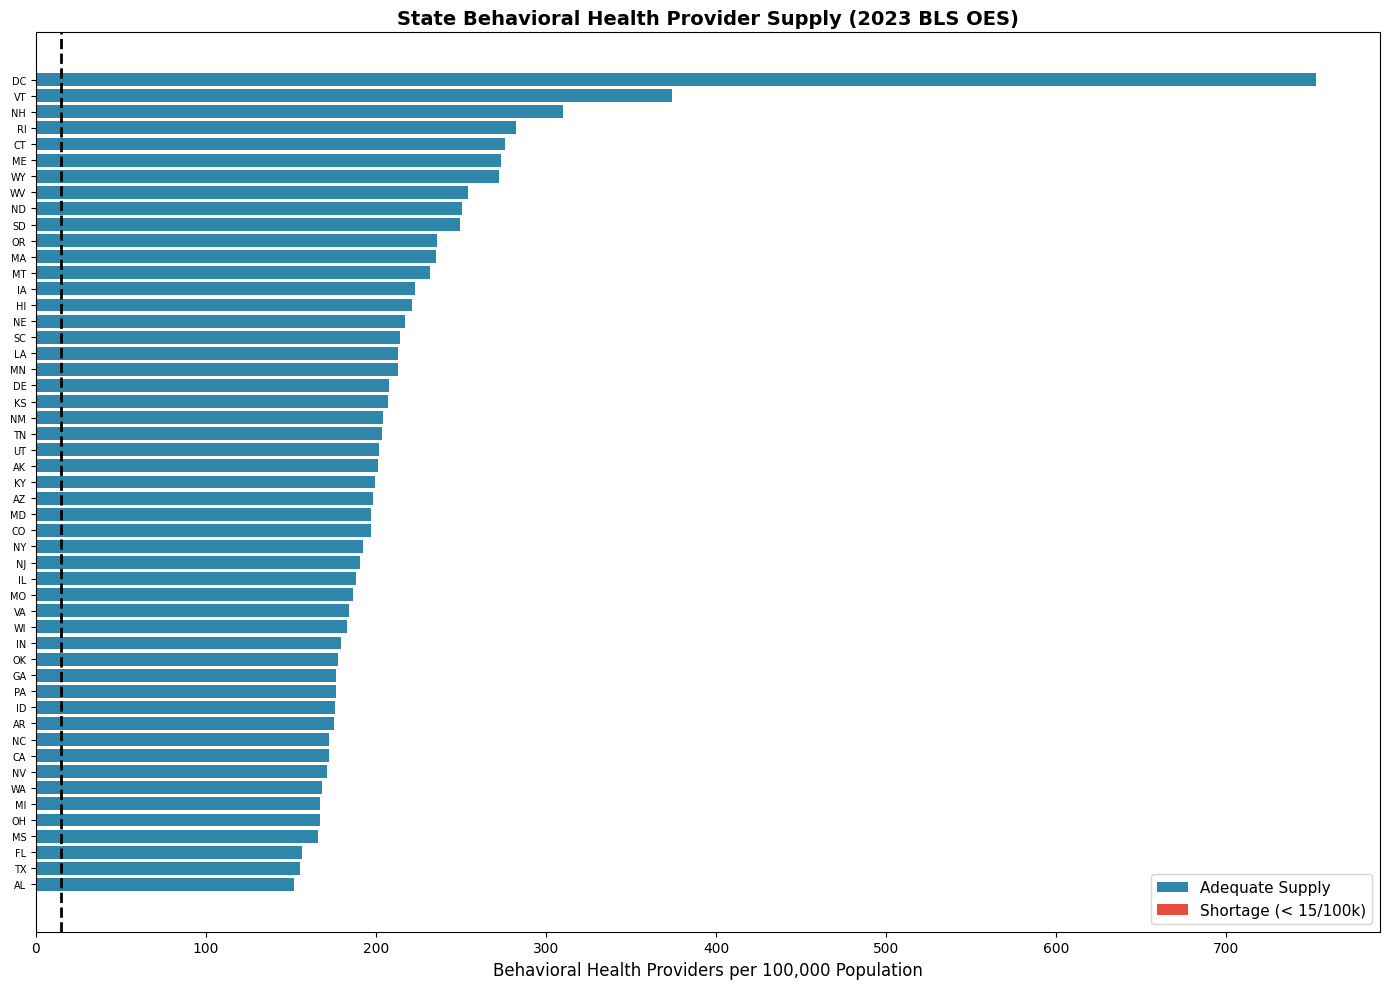

Saved: provider_supply_by_state.png


In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 10))

df_plot = df_providers.sort_values('providers_per_100k', ascending=True)
colors = ['#E74C3C' if x else '#2E86AB' for x in df_plot['provider_shortage']]

ax.barh(df_plot['state_abbrev'], df_plot['providers_per_100k'], color=colors)
ax.axvline(x=SHORTAGE_THRESHOLD, color='black', linestyle='--', linewidth=2, label=f'Shortage Threshold ({SHORTAGE_THRESHOLD}/100k)')
ax.set_xlabel('Behavioral Health Providers per 100,000 Population', fontsize=12)
ax.set_title('State Behavioral Health Provider Supply (2023 BLS OES)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=7)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E86AB', label='Adequate Supply'),
    Patch(facecolor='#E74C3C', label=f'Shortage (< {SHORTAGE_THRESHOLD}/100k)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'provider_supply_by_state.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: provider_supply_by_state.png")

## 8. Octave States vs. Expansion States: Visual Comparison

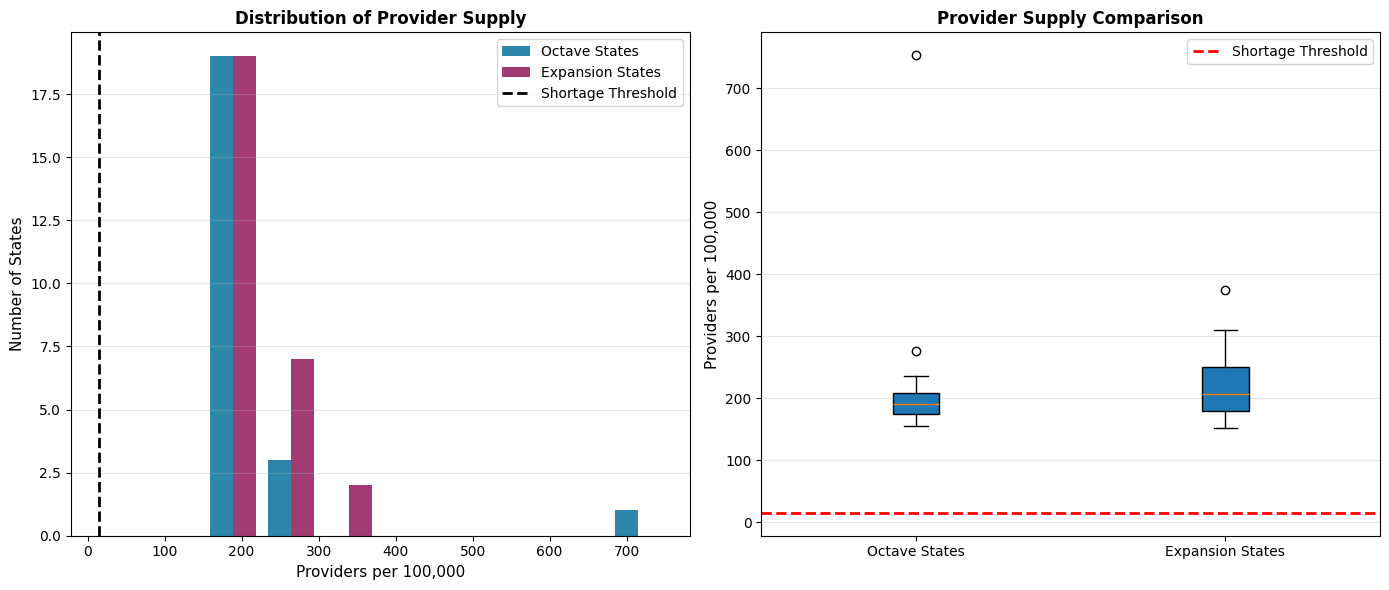

Saved: octave_vs_expansion_provider_supply.png


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Distribution of providers per 100k
octave_rates = df_providers[df_providers['is_octave_state']]['providers_per_100k']
expansion_rates = df_providers[~df_providers['is_octave_state']]['providers_per_100k']

ax1.hist([octave_rates, expansion_rates], label=['Octave States', 'Expansion States'], bins=8, color=['#2E86AB', '#A23B72'])
ax1.axvline(x=SHORTAGE_THRESHOLD, color='black', linestyle='--', linewidth=2, label='Shortage Threshold')
ax1.set_xlabel('Providers per 100,000', fontsize=11)
ax1.set_ylabel('Number of States', fontsize=11)
ax1.set_title('Distribution of Provider Supply', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# Right: Box plot comparison
data_to_plot = [octave_rates, expansion_rates]
ax2.boxplot(data_to_plot, labels=['Octave States', 'Expansion States'], patch_artist=True)
ax2.axhline(y=SHORTAGE_THRESHOLD, color='red', linestyle='--', linewidth=2, label='Shortage Threshold')
ax2.set_ylabel('Providers per 100,000', fontsize=11)
ax2.set_title('Provider Supply Comparison', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'octave_vs_expansion_provider_supply.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: octave_vs_expansion_provider_supply.png")

## 9. Save Output

In [13]:
# --- Save the provider counts table ---

output_path = os.path.join(OUTPUT_DIR, 'state_provider_counts.csv')
df_providers.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print(f"Shape: {df_providers.shape}")
print(f"\nColumns: {list(df_providers.columns)}")
print(f"\nKey new columns:")
print(f"  nurse_practitioners_total — BLS total NPs (SOC 291171)")
print(f"  estimated_pmhnp — 5% of total NPs (AANP estimate)")
print(f"  npi_pmhnp_count — NPI Registry actual PMHNP count")
print(f"  pmhnp_best_estimate — NPI where available, BLS fallback")
print(f"  total_prescribers_adj — psychiatrists + PMHNP best estimate")
print(f"\nThis output feeds into NB03+ for payer, demand, and expansion analysis.")

Saved: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion/data/outputs/nb02_provider_landscape/state_provider_counts.csv
Shape: (51, 30)

Columns: ['state_name', 'state_abbrev', 'fips_code', 'is_octave_state', 'psychiatrists', 'psychologists', 'mh_counselors', 'mft_therapists', 'sw_social_workers', 'sa_counselors', 'nurse_practitioners_total', 'estimated_pmhnp', 'total_therapy_providers', 'total_prescribers', 'total_bh_providers', 'total_population', 'population_18_plus', 'providers_per_100k', 'providers_per_100k_adult', 'prescribers_per_100k', 'npi_pmhnp_exact', 'npi_pmhnp_estimate', 'npi_sample_share', 'npi_method', 'npi_hit_cap', 'pmhnp_best_estimate', 'total_bh_providers_adj', 'total_prescribers_adj', 'prescribers_per_100k_adj', 'provider_shortage']

Key new columns:
  nurse_practitioners_total — BLS total NPs (SOC 291171)
  estimated_pmhnp — 5% of total NPs (AANP estimate)
  npi_

---

## Next: NB03 — Payer Mix & Insurance Coverage

NB03 will use `state_population_base.csv` and `state_provider_counts.csv` to map Octave's payer partners and estimate covered lives by state.